In [1]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from matplotlib import cm
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
#!pip install Pillow

In [3]:
from PIL import Image

Image format: JPEG; shape: (640, 427); color scheme: RGB


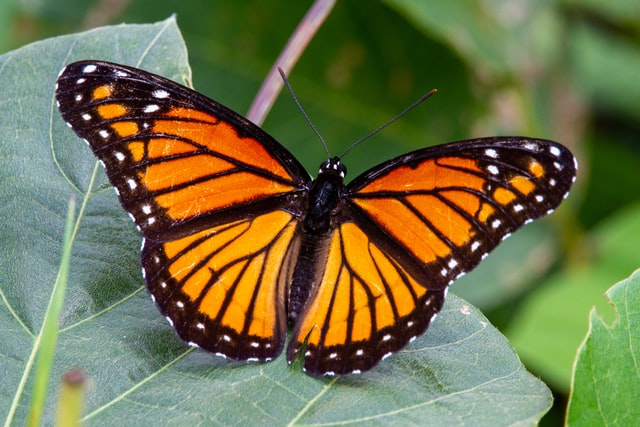

In [4]:
img = Image.open("./butterfly.jpg")
print(f"Image format: {img.format}; shape: {img.size}; color scheme: {img.mode}")
img

In [5]:
# преобразуем изображение в массив
img_matrix = np.array(img)

# (высота, ширина, число каналов)
print(f"Image array shape: {img_matrix.shape}")

plt.imshow(img_matrix);

Image array shape: (427, 640, 3)


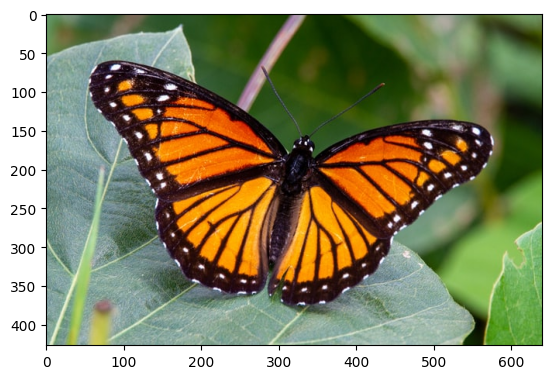

In [6]:
plt.imshow(img_matrix)
plt.show()

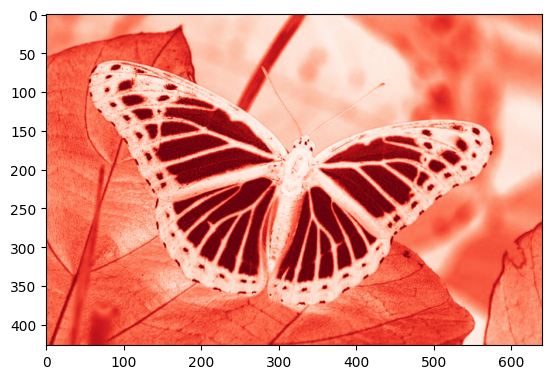

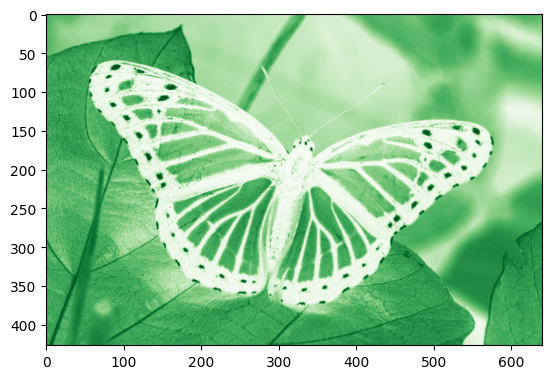

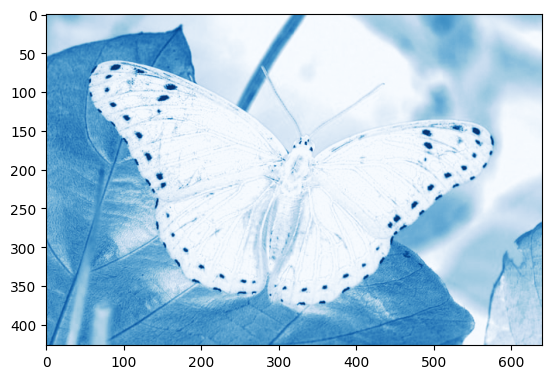

In [7]:
# посмотрим на все каналы изображения отдельно
plt.imshow(img_matrix[:, :, 0], cmap=cm.Reds)
plt.show()

plt.imshow(img_matrix[:, :, 1], cmap=cm.Greens)
plt.show()

plt.imshow(img_matrix[:, :, 2], cmap=cm.Blues)
plt.show()

In [8]:
img_matrix[:, :, 2]

array([[107, 107, 107, ...,  99,  97,  95],
       [107, 107, 107, ...,  99,  96,  95],
       [107, 107, 106, ...,  98,  96,  94],
       ...,
       [164, 173, 159, ...,  70,  62,  62],
       [162, 171, 163, ...,  66,  58,  60],
       [159, 167, 162, ...,  64,  56,  55]], shape=(427, 640), dtype=uint8)

In [9]:
import torch.nn as nn

In [10]:
nn.Conv2d

torch.nn.modules.conv.Conv2d

In [11]:
# свертка -- бегаем с помощью ядра-матрицы по матрице изображения и ищем паттерны; ядро подбирается как матрица весов
# в духе линейной регрессии
# stride (шаг) напрямую связан с понятием поля обзора: как модно быстрее отодвинуться от картинки,
# чтобы в общих чертах идентифицировать, что на ней изображено;
# maxpool более агрессивный вариант такой экономии;
# чаще всего их чередуют: свертка -- макспул -- свертка -- макспул...
# flatten вытягивает матрицу в вектор, который потом посылаем в обычный линейный классификатор

In [12]:
import torch
import torchvision

import torch.nn.functional as F
from torch import nn

from torchvision import transforms as T
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

In [13]:
# 1. Подгружаем данные

In [14]:
# Через Compose можно задать сразу несколько функция для трансформации данных перед подачей в нейросеть

transform = torchvision.transforms.Compose([
    # Перетворення PIL Image або ndarray в torch.Tensor
    T.ToTensor(),
    # Нормалізація каналів (напр., mean та std)
    # Нормалізація каналів (mean та std) потрібна для того, щоб стабілізувати та значно прискорити навчання нейромережі.
    # Після конвертації зображення в тензор (ToTensor), значення пікселів зазвичай перебувають у діапазоні від 0 до 1.
    # Нормалізація переводить ці значення у діапазон, де середнє значення приблизно дорівнює 0, а стандартне відхилення — 1.
    T.Normalize((0.1307,), (0.3081,)),
])

In [17]:
# подгружаем сеты и делаем из них батчи для тренировки и валидации

train_set = MNIST('.MNIST', transform=transform, train=True, download=True)
val_set = MNIST('.MNIST', transform=transform, train=False, download=True)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size     = 256,
    shuffle        = True,
    num_workers    = 0
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size    = 4096,
    shuffle       = False,
    num_workers   = 0
)

In [16]:
# 00:30:00

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc, wandb_project=None):
    """Одна эпоха обучения"""
    train_loss, train_accuracy = 0.0, 0.0
    model.train()
    for images, labels in tqdm(train_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.shape[0]
        train_accuracy += (logits.argmax(dim=1) == labels).sum().item()

        if wandb_project:
            metrics = {
                "batch-train/loss": loss.item()
            }
            wandb.log(metrics)

    train_loss /= len(train_loader.dataset)
    train_accuracy /= len(train_loader.dataset)
    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, val_loader, tqdm_desc):
    """Прогнозы на валидации"""

    val_loss, val_accuracy = 0.0, 0.0
    model.eval()
    for images, labels in tqdm(val_loader, desc=tqdm_desc):
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        val_loss += loss.item() * images.shape[0]
        val_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy /= len(val_loader.dataset)
    return val_loss, val_accuracy


def train(model, optimizer, criterion, train_loader, val_loader, num_epochs, scheduler=None, wandb_project=None):
    """Обучение модели"""
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    # подключаем wandb
    if wandb_project:
        wandb.init(project=wandb_project)
        wandb.watch(model)

    for epoch in range(1, num_epochs + 1):
        train_loss, train_accuracy = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}',
            wandb_project=wandb_project
        )
        val_loss, val_accuracy = validation_epoch(
            model, criterion, val_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # функция для смены lr по расписанию
        if scheduler is not None:
            scheduler.step()

        if wandb_project:
            metrics = {
                "train/loss": train_loss / len(train_loader.dataset),
                "train/accuracy": train_accuracy / len(train_loader.dataset),
                "val/loss": val_loss,
                "val/accuracy": val_accuracy
            }
            wandb.log(metrics)
        else:
          plot_losses(train_losses, val_losses, train_accuracies, val_accuracies)

    # печатаем метрики
    print(f"Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}")

In [18]:
from torch import nn

In [ ]:
class FcNet(nn.Module):

    # инициализируем слои
    def __init__(self, input_shape, hide_neurons=32, num_classes=10):
        # инициализируем функцию-конструктор из модуля
        super().__init__()
        # объявляем модель и что мы можем в ней подобовлять
        self.model = nn.Sequential(

            nn.Flatten(), # превращаем картинку 28 на 28 в вектор 784
            nn.Linear(input_shape, hide_neurons), # линейный слой, преобразует вектор 784 в вектор 32
            nn.ReLU(), # нелинейность
            nn.Linear(hide_neurons, hide_neurons // 2), # линейный слой, преобразует вектор 784 в вектор 16
            nn.ReLU(), # нелинейность
            nn.Linear(hide_neurons // 2, num_classes) # линейный слой, преобразует вектор 784 в вектор 10
            
        )

    # прогоняем по слоям
    def forward(self, x):
        # распаковываем элемент в матрицу, начиная со второго элемента (первый -- не координата)
        return self.model(x)

In [ ]:
IMG_SIZE = 28
NUM_EPOCH = 5

model_fc = FcNet(IMG_SIZE**2)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_fc.parameters(), lr=0.01, momentum=0)

In [ ]:
tain(

    model_fc, optimizer, criterion,
    train_loader, val_loader,
    NUM_EPOCH
    
)

In [19]:
# 50:00